# G0 Analysis

In [1]:
import os, re, json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# ── ROOT 자동 감지 ──────────────────────────────────────────────
ROOT = Path(os.environ.get('G0_ROOT', Path.cwd()))

# ── SEQS: seqs* 하위 디렉토리에서 자동 감지 ──────────────────────
SEQS = sorted(
    int(p.name.replace('seqs', ''))
    for p in ROOT.iterdir()
    if p.is_dir() and re.fullmatch(r'seqs\d+', p.name)
)
print(f'ROOT = {ROOT}')
print(f'SEQS = {SEQS}')

# ── GPU-only baseline ────────────────────────────────────────────
GPU_BASELINE_DIR = ROOT / 'gpu_only_baseline'
GPU_BASELINE_JSON = GPU_BASELINE_DIR / 'gpu_only.json'
gpu_baseline = json.loads(GPU_BASELINE_JSON.read_text()) if GPU_BASELINE_JSON.exists() else None
print(f'GPU baseline: {"found" if gpu_baseline else "not found"} ({GPU_BASELINE_JSON})')

# ── 메타 수집 ────────────────────────────────────────────────────
def load_meta(seqs_val):
    d = ROOT / f'seqs{seqs_val}'
    bench, feat, sysinfo, env_vars = {}, {}, {}, {}
    if (d / 'hybrid.json').exists():
        bench = json.loads((d / 'hybrid.json').read_text())
    if (d / 'applied_features.json').exists():
        feat = json.loads((d / 'applied_features.json').read_text())
    if (d / 'system_info.json').exists():
        sysinfo = json.loads((d / 'system_info.json').read_text())
    for line in (d / 'env_snapshot.txt').read_text().splitlines() if (d / 'env_snapshot.txt').exists() else []:
        if '=' in line:
            k, v = line.split('=', 1)
            env_vars[k.strip()] = v.strip()
    resolved_max_seqs = None
    boot_log = d / 'hybrid_server_boot.log'
    if boot_log.exists():
        m = re.search(r'\[HYBRID-RESOLVE\].*?max_seqs=(\d+)', boot_log.read_text())
        if m:
            resolved_max_seqs = int(m.group(1))
    return bench, feat, sysinfo, env_vars, resolved_max_seqs

metas = {s: load_meta(s) for s in SEQS}

# ── 대표값 (첫 번째 seqs 기준) ──────────────────────────────────
s0 = SEQS[0]
bench0, feat0, sys0, env0, _ = metas[s0]

model_id    = bench0.get('model_id', feat0.get('model', '?'))
num_prompts = bench0.get('num_prompts', '?')
avg_in  = bench0['total_input_tokens']  / bench0['num_prompts'] if 'total_input_tokens'  in bench0 else '?'
avg_out = bench0['total_output_tokens'] / bench0['num_prompts'] if 'total_output_tokens' in bench0 else '?'
req_rate = bench0.get('request_rate', '?')

hc = feat0.get('hybrid_config', {})
num_cpu_engines  = hc.get('num_cpu_engines', '?')
routing_strategy = hc.get('routing_strategy', '?')
routing_priority = hc.get('routing_priority', '?')

threads_per_engine = None
boot0 = ROOT / f'seqs{s0}' / 'hybrid_server_boot.log'
if boot0.exists():
    m = re.search(r'\[HYBRID-RESOLVE\].*?threads=(\d+)', boot0.read_text())
    if m:
        threads_per_engine = int(m.group(1))

sys0 = sys0 if sys0 else {}
numa_nodes = sys0.get('num_nodes', '?')
seqs_map   = {s: metas[s][4] for s in SEQS}

profile_on    = env0.get('VLLM_HYBRID_PROFILE', '0')
sublayer_on   = env0.get('VLLM_HYBRID_PROFILE_SUBLAYER', '0')
profile_every = env0.get('VLLM_HYBRID_PROFILE_EVERY', '?')

# ── 헤더 출력 ────────────────────────────────────────────────────
lines = [
    f'**Model**: `{model_id}`  ',
    f'**Hardware**: {numa_nodes}-socket NUMA, {num_cpu_engines} CPU engine(s), {threads_per_engine} threads/engine  ',
    f'**Workload**: {num_prompts} req, avg {avg_in:.0f} input / {avg_out:.0f} output tokens, rate={req_rate}  ',
    f'**Routing**: {routing_strategy} + {routing_priority}  ',
    f'**cpu_max_num_seqs sweep**: { {s: seqs_map[s] for s in SEQS} }  ',
    f'**Profile**: VLLM_HYBRID_PROFILE={profile_on}, SUBLAYER={sublayer_on}, EVERY={profile_every}  ',
    f'**GPU-only baseline**: {"available ✓" if gpu_baseline else "not found"}',
]
display(Markdown('\n'.join(lines)))

ROOT = /mnt/d/projects/vllm_hybrid/measurement_results/H100x8/g0_02_strat_length_aware
SEQS = [1]
GPU baseline: not found (/mnt/d/projects/vllm_hybrid/measurement_results/H100x8/g0_02_strat_length_aware/gpu_only_baseline/gpu_only.json)


**Model**: `Qwen/Qwen2.5-32B-Instruct`  
**Hardware**: ?-socket NUMA, 2 CPU engine(s), 56 threads/engine  
**Workload**: 500 req, avg 127 input / 123 output tokens, rate=inf  
**Routing**: length-aware + cpu-first  
**cpu_max_num_seqs sweep**: {1: 1}  
**Profile**: VLLM_HYBRID_PROFILE=1, SUBLAYER=1, EVERY=10  
**GPU-only baseline**: not found

## 1. Profile 로그 파싱 — sublayer breakdown 시계열

In [2]:
# [HYBRID-CPU-PROFILE] sublayer line regex
# 예: step=5 reqs=0 tokens=1 threads=16 total=93.4ms qkv=4.8ms(28) o=3.8ms(28) gate_up=38.4ms(28) down=19.4ms(28) norm=2.9ms(56) act=0.8ms(28) attn_core=17.9ms(28) other=16.6ms
LINE_RE = re.compile(
    r'\[HYBRID-CPU-PROFILE\] step=(\d+) reqs=(\S+) tokens=(\d+) '
    r'threads=(\d+) total=([\d.]+)ms '
    r'qkv=([\d.]+)ms\((\d+)\) o=([\d.]+)ms\((\d+)\) '
    r'gate_up=([\d.]+)ms\((\d+)\) down=([\d.]+)ms\((\d+)\) '
    r'norm=([\d.]+)ms\((\d+)\) act=([\d.]+)ms\((\d+)\) '
    r'attn_core=([\d.]+)ms\((\d+)\) other=([\d.]+)ms'
)

def parse_profile(log_path):
    rows = []
    if not log_path.exists():
        return pd.DataFrame()
    for line in log_path.read_text(errors='replace').splitlines():
        m = LINE_RE.search(line)
        if not m:
            continue
        g = m.groups()
        rows.append({
            'step': int(g[0]), 'reqs': g[1], 'tokens': int(g[2]),
            'threads': int(g[3]), 'total_ms': float(g[4]),
            'qkv_ms': float(g[5]), 'qkv_n': int(g[6]),
            'o_ms': float(g[7]), 'o_n': int(g[8]),
            'gate_up_ms': float(g[9]), 'gate_up_n': int(g[10]),
            'down_ms': float(g[11]), 'down_n': int(g[12]),
            'norm_ms': float(g[13]), 'norm_n': int(g[14]),
            'act_ms': float(g[15]), 'act_n': int(g[16]),
            'attn_core_ms': float(g[17]), 'attn_core_n': int(g[18]),
            'other_ms': float(g[19]),
        })
    return pd.DataFrame(rows)

dfs = {}
for s in SEQS:
    p = ROOT / f'seqs{s}' / 'hybrid_server_run.log'
    dfs[s] = parse_profile(p)
    print(f'seqs={s}: {len(dfs[s])} profile samples  (log={p.exists()})')

seqs=1: 37 profile samples  (log=True)


## 2. Bench 결과 (wall, TPOT, TTFT)

In [3]:
def extract_bench_row(label, d, seqs_val=None):
    return {
        'label': label,
        'seqs': seqs_val,
        'wall_s': d.get('duration'),
        'req_throughput': d.get('request_throughput'),
        'out_tps': d.get('output_throughput'),
        'tpot_mean': d.get('mean_tpot_ms'),
        'tpot_p99': d.get('p99_tpot_ms'),
        'ttft_mean': d.get('mean_ttft_ms'),
        'ttft_p99': d.get('p99_ttft_ms'),
    }

bench_rows = []

# GPU-only baseline (첫 행)
if gpu_baseline:
    bench_rows.append(extract_bench_row('GPU-only', gpu_baseline))

# hybrid sweep
for s in SEQS:
    b = metas[s][0]  # bench dict
    if not b:
        continue
    bench_rows.append(extract_bench_row(f'hybrid seqs={seqs_map.get(s, s)}', b, seqs_val=s))

bench_df = pd.DataFrame(bench_rows).set_index('label')
bench_df

,seqs,wall_s,req_throughput,out_tps,tpot_mean,tpot_p99,ttft_mean,ttft_p99
label,,,,,,,,
hybrid seqs=1,1,96.913454,5.159242,636.289365,65.292855,85.629459,1462.78632,2204.203472


## 3. Batch scaling — step time per num_seqs

In [4]:
# 각 run 의 profile steps 에서 median total_ms + sublayer 기여도
summary = []
for s in SEQS:
    df = dfs[s]
    if df.empty:
        continue
    # 초기 몇 step 은 warmup 이므로 drop
    d = df.iloc[3:] if len(df) > 5 else df
    summary.append({
        'seqs': s,
        'samples': len(d),
        'total_med': d['total_ms'].median(),
        'qkv_med': d['qkv_ms'].median(),
        'o_med': d['o_ms'].median(),
        'gate_up_med': d['gate_up_ms'].median(),
        'down_med': d['down_ms'].median(),
        'norm_med': d['norm_ms'].median(),
        'act_med': d['act_ms'].median(),
        'attn_core_med': d['attn_core_ms'].median(),
        'other_med': d['other_ms'].median(),
    })
if not summary:
    print('⚠ No [HYBRID-CPU-PROFILE] markers found in any hybrid_server_run.log')
    print('  → sublayer analysis skipped. Bench (wall/TPOT) analysis still works.')
    sdf = pd.DataFrame(columns=[
        'seqs', 'samples', 'total_med', 'qkv_med', 'o_med',
        'gate_up_med', 'down_med', 'norm_med', 'act_med',
        'attn_core_med', 'other_med',
        'scaling_ratio', 'linear_expected', 'scaling_efficiency'
    ]).set_index('seqs')
else:
    sdf = pd.DataFrame(summary).set_index('seqs')
    # batch_scaling_ratio = total(N) / total(1)
    base = sdf.loc[1, 'total_med'] if 1 in sdf.index else sdf.iloc[0]['total_med']
    sdf['scaling_ratio'] = sdf['total_med'] / base
    sdf['linear_expected'] = sdf.index.values / sdf.index[0]
    sdf['scaling_efficiency'] = sdf['linear_expected'] / sdf['scaling_ratio']
sdf

,samples,total_med,qkv_med,o_med,gate_up_med,down_med,norm_med,act_med,attn_core_med,other_med,scaling_ratio,linear_expected,scaling_efficiency
seqs,,,,,,,,,,,,,
1,34,544.1,41.5,32.25,224.75,140.25,22.75,8.45,134.3,39.9,1.0,1.0,1.0


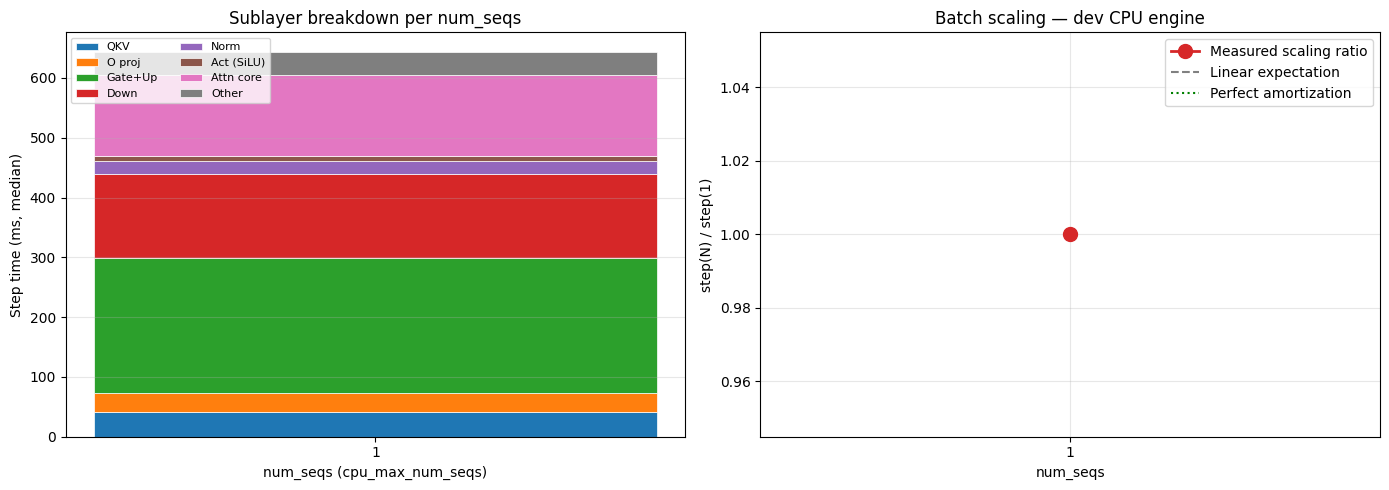

In [5]:
cols = ['qkv_med', 'o_med', 'gate_up_med', 'down_med', 'norm_med',
        'act_med', 'attn_core_med', 'other_med']
labels = ['QKV', 'O proj', 'Gate+Up', 'Down', 'Norm', 'Act (SiLU)',
          'Attn core', 'Other']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
          '#8c564b', '#e377c2', '#7f7f7f']

if sdf.empty:
    print('⚠ sdf 비어 있음 — sublayer / scaling plot 생략 (profile 데이터 없음)')
else:
    # Plot 1: sublayer stacked bars (per num_seqs)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    bottom = np.zeros(len(sdf))
    for c, label, color in zip(cols, labels, colors):
        vals = sdf[c].values.astype(float)
        ax.bar(sdf.index.astype(str), vals, bottom=bottom, label=label,
               color=color, edgecolor='white', linewidth=0.5)
        bottom += vals
    ax.set_xlabel('num_seqs (cpu_max_num_seqs)')
    ax.set_ylabel('Step time (ms, median)')
    ax.set_title('Sublayer breakdown per num_seqs')
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    ax.grid(True, axis='y', alpha=0.3)

    # Plot 2: scaling ratio vs linear expectation
    ax = axes[1]
    seqs_arr = sdf.index.astype(float).values
    ax.plot(seqs_arr, sdf['scaling_ratio'].values, 'o-',
            color='#d62728', linewidth=2, markersize=10,
            label='Measured scaling ratio')
    ax.plot(seqs_arr, seqs_arr / seqs_arr[0], '--',
            color='gray', linewidth=1.5, label='Linear expectation')
    ax.plot(seqs_arr, np.ones_like(seqs_arr), ':',
            color='green', linewidth=1.5, label='Perfect amortization')
    ax.set_xscale('log', base=2)
    ax.set_xticks(seqs_arr)
    ax.set_xticklabels([str(int(s)) for s in seqs_arr])
    ax.set_xlabel('num_seqs')
    ax.set_ylabel('step(N) / step(1)')
    ax.set_title('Batch scaling — dev CPU engine')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(ROOT / 'analysis_summary.png',
                dpi=130, bbox_inches='tight')
    plt.show()

## 4. Per-sublayer scaling (어느 sublayer 가 폭증?)

In [6]:
# 각 sublayer 의 step(N) / step(1) 비율
sub_cols = ['qkv_med', 'o_med', 'gate_up_med', 'down_med',
            'norm_med', 'act_med', 'attn_core_med']
sub_labels = ['QKV', 'O proj', 'Gate+Up', 'Down', 'Norm', 'Act', 'Attn core']

if 1 in sdf.index:
    base_row = sdf.loc[1]
    ratio_df = pd.DataFrame({
        label: sdf[col] / base_row[col]
        for col, label in zip(sub_cols, sub_labels)
    })
    ratio_df['linear'] = sdf.index / 1
else:
    ratio_df = None
ratio_df

,QKV,O proj,Gate+Up,Down,Norm,Act,Attn core,linear
seqs,,,,,,,,
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


/tmp/ipykernel_256523/387491810.py:16: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256523/387491810.py:16: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/mystous/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/mystous/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


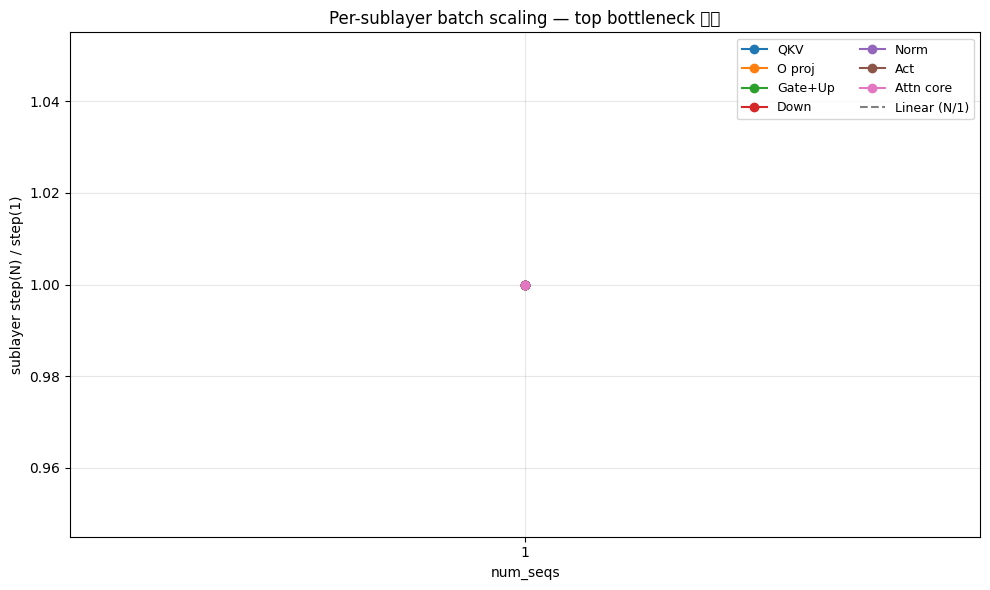

In [7]:
if ratio_df is not None:
    fig, ax = plt.subplots(figsize=(10, 6))
    xs = ratio_df.index.astype(float).values
    for label, color in zip(sub_labels, colors[:len(sub_labels)]):
        ax.plot(xs, ratio_df[label].values, 'o-', label=label, color=color)
    ax.plot(xs, ratio_df['linear'].values, '--', color='gray',
            linewidth=1.5, label='Linear (N/1)')
    ax.set_xscale('log', base=2)
    ax.set_xticks(xs)
    ax.set_xticklabels([str(int(s)) for s in xs])
    ax.set_xlabel('num_seqs')
    ax.set_ylabel('sublayer step(N) / step(1)')
    ax.set_title('Per-sublayer batch scaling — top bottleneck 식별')
    ax.legend(fontsize=9, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 5. Bench wall vs num_seqs

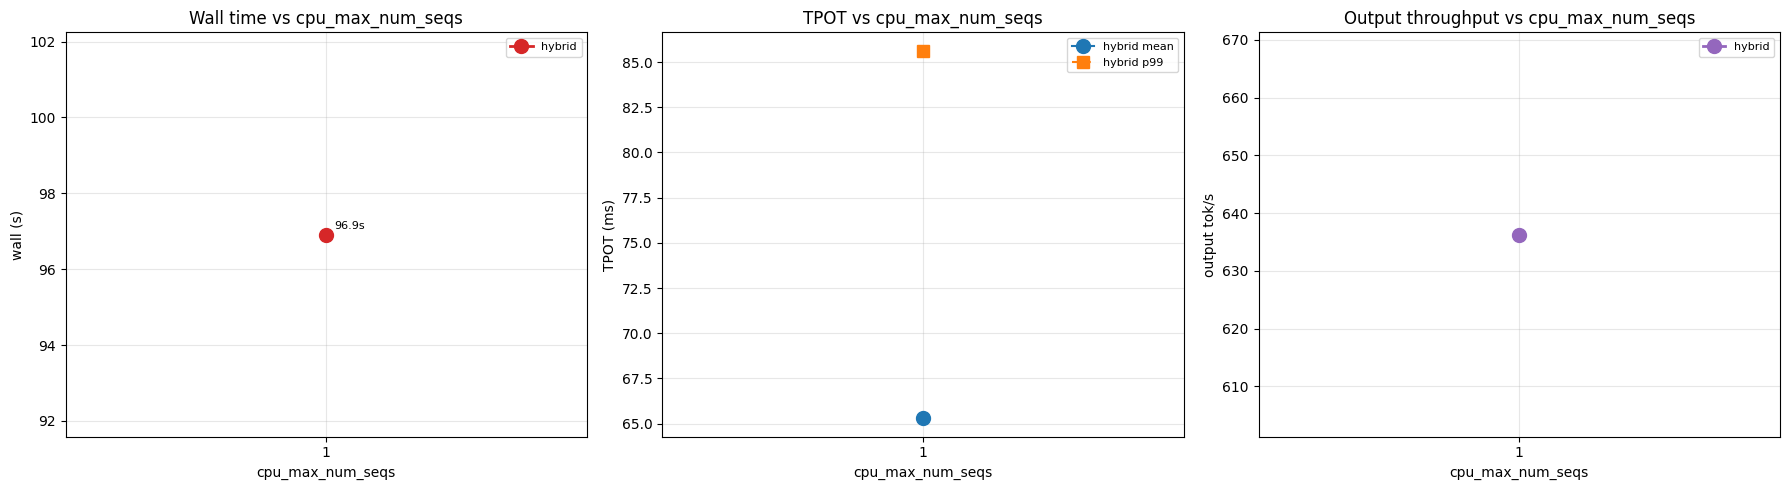

In [8]:
hybrid_df = bench_df[bench_df['seqs'].notna()].copy()
hybrid_df['seqs'] = hybrid_df['seqs'].astype(int)

if not hybrid_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    def add_baseline(ax, val, label, color='#2ca02c'):
        if gpu_baseline and val is not None:
            ax.axhline(val, color=color, linewidth=1.5, linestyle='--', alpha=0.8)
            ax.text(hybrid_df['seqs'].iloc[-1], val, f'  {label}\n  {val:.1f}',
                    color=color, fontsize=8, va='bottom')

    # ── Plot 1: wall time ──────────────────────────────────────
    ax = axes[0]
    ax.plot(hybrid_df['seqs'], hybrid_df['wall_s'], 'o-',
            color='#d62728', markersize=10, linewidth=2, label='hybrid')
    add_baseline(ax, gpu_baseline.get('duration') if gpu_baseline else None, 'GPU-only')
    ax.set_xscale('log', base=2)
    ax.set_xticks(hybrid_df['seqs'])
    ax.set_xticklabels([str(s) for s in hybrid_df['seqs']])
    ax.set_xlabel('cpu_max_num_seqs')
    ax.set_ylabel('wall (s)')
    ax.set_title('Wall time vs cpu_max_num_seqs')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    for _, r in hybrid_df.iterrows():
        ax.annotate(f"{r['wall_s']:.1f}s", (r['seqs'], r['wall_s']),
                    textcoords='offset points', xytext=(6, 4), fontsize=8)

    # ── Plot 2: TPOT ───────────────────────────────────────────
    ax = axes[1]
    ax.plot(hybrid_df['seqs'], hybrid_df['tpot_mean'], 'o-',
            label='hybrid mean', color='#1f77b4', markersize=10)
    ax.plot(hybrid_df['seqs'], hybrid_df['tpot_p99'], 's--',
            label='hybrid p99', color='#ff7f0e', markersize=8)
    if gpu_baseline:
        add_baseline(ax, gpu_baseline.get('mean_tpot_ms'), 'GPU-only mean')
    ax.set_xscale('log', base=2)
    ax.set_xticks(hybrid_df['seqs'])
    ax.set_xticklabels([str(s) for s in hybrid_df['seqs']])
    ax.set_xlabel('cpu_max_num_seqs')
    ax.set_ylabel('TPOT (ms)')
    ax.set_title('TPOT vs cpu_max_num_seqs')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ── Plot 3: output throughput ──────────────────────────────
    ax = axes[2]
    ax.plot(hybrid_df['seqs'], hybrid_df['out_tps'], 'o-',
            color='#9467bd', markersize=10, linewidth=2, label='hybrid')
    if gpu_baseline:
        add_baseline(ax, gpu_baseline.get('output_throughput'), 'GPU-only')
    ax.set_xscale('log', base=2)
    ax.set_xticks(hybrid_df['seqs'])
    ax.set_xticklabels([str(s) for s in hybrid_df['seqs']])
    ax.set_xlabel('cpu_max_num_seqs')
    ax.set_ylabel('output tok/s')
    ax.set_title('Output throughput vs cpu_max_num_seqs')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(ROOT / 'analysis_bench.png', dpi=130, bbox_inches='tight')
    plt.show()

## 6. Applied Features Manifest 확인

In [9]:
for s in SEQS:
    mpath = ROOT / f'seqs{s}' / 'applied_features.json'
    if not mpath.exists():
        print(f'seqs={s}: no manifest')
        continue
    m = json.loads(mpath.read_text())
    enabled = {k: v for k, v in m['features'].items()
               if v and v != '0' and v != 'off'}
    print(f"seqs={s}: git={m['git_sha'][:8]} "
          f"profile={m['profile_meta']['VLLM_HYBRID_PROFILE']} "
          f"sublayer={m['profile_meta']['VLLM_HYBRID_PROFILE_SUBLAYER']} "
          f"enabled={list(enabled.keys()) or 'none'}")

seqs=1: git=0a40311c profile=1 sublayer=1 enabled=none


## 7. G0 Gate 판정

- **G0 통과 조건**: num_seqs sweep 확보 + sublayer breakdown
- **G1 조건**: `scaling_ratio(4/1) ≤ 2×`
- **G2 조건**: `scaling_ratio(4/1) ≤ 1.5×`

In [10]:
# Top bottleneck identification
if 1 in sdf.index:
    top = sdf.loc[1, sub_cols].sort_values(ascending=False)
    print('Top bottleneck @ seqs=1:')
    for c, v in top.items():
        label = sub_labels[sub_cols.index(c)]
        pct = v / sdf.loc[1, 'total_med'] * 100
        print(f'  {label:12s} {v:6.2f}ms ({pct:.1f}%)')

# Gate evaluation
if 4 in sdf.index and 1 in sdf.index:
    ratio_4_1 = sdf.loc[4, 'total_med'] / sdf.loc[1, 'total_med']
    print(f'\nscaling_ratio(4/1) = {ratio_4_1:.2f}x')
    if ratio_4_1 <= 1.5:
        print('  -> G2 pass')
    elif ratio_4_1 <= 2.0:
        print('  -> G1 pass')
    else:
        print('  -> pre-G1 (batch scaling 실패)')

if 16 in sdf.index and 1 in sdf.index:
    ratio_16_1 = sdf.loc[16, 'total_med'] / sdf.loc[1, 'total_med']
    print(f'scaling_ratio(16/1) = {ratio_16_1:.2f}x (linear 기대 16x)')
    print(f'  failure factor = {16/ratio_16_1:.1f}x (16/ratio)')

Top bottleneck @ seqs=1:
  Gate+Up      224.75ms (41.3%)
  Down         140.25ms (25.8%)
  Attn core    134.30ms (24.7%)
  QKV           41.50ms (7.6%)
  O proj        32.25ms (5.9%)
  Norm          22.75ms (4.2%)
  Act            8.45ms (1.6%)


## 8. CPU / GPU Utilization (monitor CSV 기반)

In [11]:
# Monitor CSV 로드 (per seqs)
def _n_physical(d):
    sp = d / 'system_info.json'
    if not sp.exists():
        return None
    si = json.loads(sp.read_text())
    c = si.get('cpu', {})
    return c.get('sockets', 1) * c.get('cores_per_socket', 1)

def _phys_cpu_cols(df, n_phys):
    if n_phys is None:
        return [c for c in df.columns
                if c.startswith('cpu') and c.endswith('_util_pct')
                and c != 'cpu_avg_util_pct']
    return [f'cpu{i}_util_pct' for i in range(n_phys)
            if f'cpu{i}_util_pct' in df.columns]

monitors = {}
for s in SEQS:
    cpu_p = ROOT / f'seqs{s}' / 'hybrid_monitor_cpu.csv'
    gpu_p = ROOT / f'seqs{s}' / 'hybrid_monitor_gpu.csv'
    if cpu_p.exists() and gpu_p.exists():
        monitors[s] = {
            'cpu': pd.read_csv(cpu_p),
            'gpu': pd.read_csv(gpu_p),
            'n_phys': _n_physical(ROOT / f'seqs{s}'),
        }
print({s: (len(m['cpu']), len(m['gpu'])) for s, m in monitors.items()})

{1: (139, 139)}


### 8.1 CPU / GPU 평균 utilization 시계열 (per seqs)

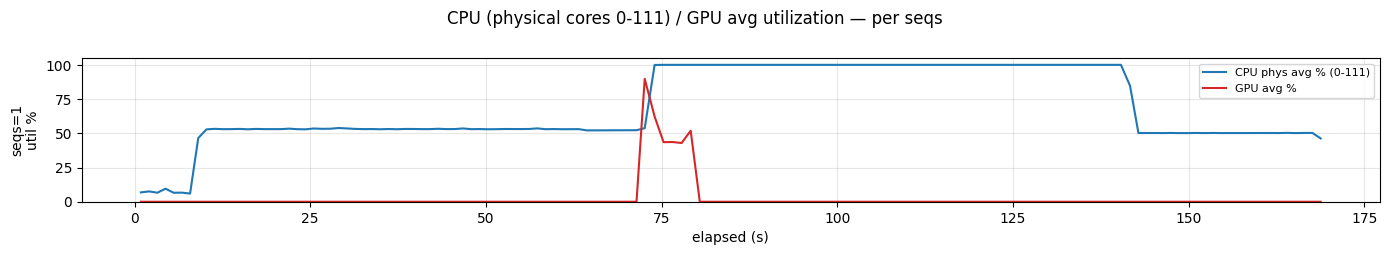

In [12]:
if monitors:
    # 물리 코어(0-111)만 평균 계산
    def phys_avg(df):
        cols = [c for c in df.columns
                if c.startswith('cpu') and c.endswith('_util_pct') and c != 'cpu_avg_util_pct'
                and int(c.replace('cpu', '').replace('_util_pct', '')) < 112]
        return df[cols].mean(axis=1)

    n = len(monitors)
    fig, axes = plt.subplots(n, 1, figsize=(14, 2.5*n), sharex=False)
    if n == 1:
        axes = [axes]
    for ax, (s, m) in zip(axes, sorted(monitors.items())):
        ax.plot(m['cpu']['elapsed_s'], phys_avg(m['cpu']),
                label='CPU phys avg % (0-111)', color='#1f77b4', linewidth=1.5)
        ax.plot(m['gpu']['elapsed_s'], m['gpu']['gpu_avg_util_pct'],
                label='GPU avg %', color='#d62728', linewidth=1.5)
        ax.set_ylabel(f'seqs={s}\nutil %')
        ax.set_ylim(0, 105)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel('elapsed (s)')
    plt.suptitle('CPU (physical cores 0-111) / GPU avg utilization — per seqs', y=1.001)
    plt.tight_layout()
    plt.savefig(ROOT / 'analysis_util_timeseries.png', dpi=130, bbox_inches='tight')
    plt.show()
else:
    print('no monitor CSVs found')

### 8.2 GPU 전력 / 메모리 시계열

H100x8 서버 레벨 전력과 메모리 사용량을 bench 진행 동안 추적.

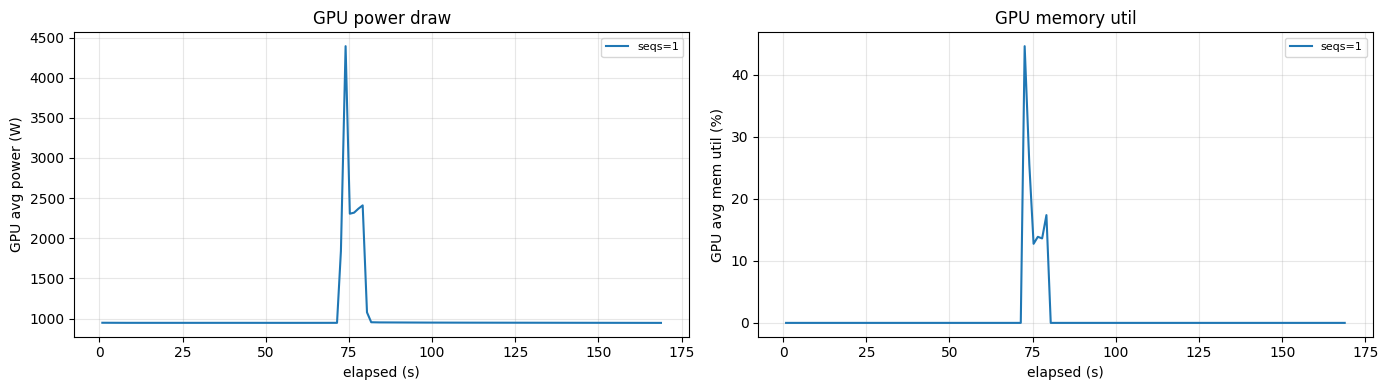

In [13]:
if monitors:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for s, m in sorted(monitors.items()):
        axes[0].plot(m['gpu']['elapsed_s'], m['gpu']['gpu_avg_power_w'], label=f'seqs={s}')
        axes[1].plot(m['gpu']['elapsed_s'], m['gpu']['gpu_avg_mem_util_pct'], label=f'seqs={s}')
    axes[0].set_xlabel('elapsed (s)'); axes[0].set_ylabel('GPU avg power (W)')
    axes[0].set_title('GPU power draw'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
    axes[1].set_xlabel('elapsed (s)'); axes[1].set_ylabel('GPU avg mem util (%)')
    axes[1].set_title('GPU memory util'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(ROOT / 'analysis_gpu_power_mem.png', dpi=130, bbox_inches='tight')
    plt.show()

### 8.3 Per-CPU utilization heatmap (가장 큰 seqs)

X축 = 시간(샘플), Y축 = CPU core #, 색 = util %.  CPU affinity 및 NUMA 활용 패턴 시각화.

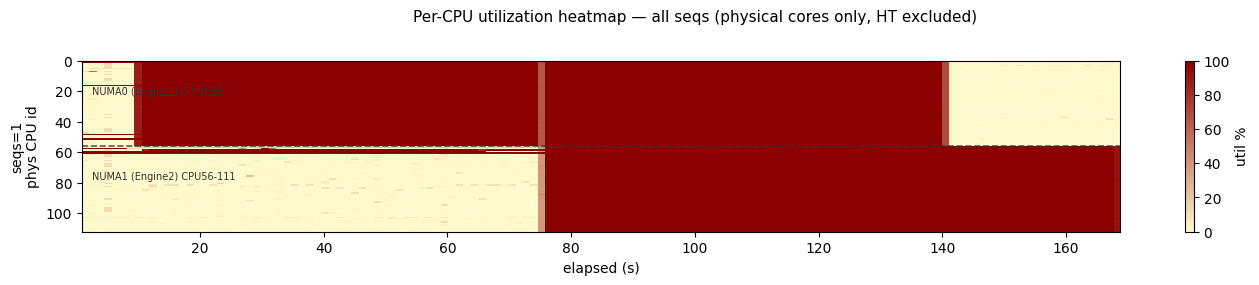

In [14]:
if monitors:
    from matplotlib.colors import LinearSegmentedColormap

    # 0% = 옅은 노란색, 100% = 짙은 빨간색
    cmap_yr = LinearSegmentedColormap.from_list('yellow_red', ['#FFFACD', '#8B0000'])

    def get_phys_mat(df):
        cols = sorted(
            [c for c in df.columns
             if c.startswith('cpu') and c.endswith('_util_pct') and c != 'cpu_avg_util_pct'
             and int(c.replace('cpu', '').replace('_util_pct', '')) < 112],
            key=lambda c: int(c.replace('cpu', '').replace('_util_pct', ''))
        )
        return df[cols].T.values, df['elapsed_s'].values

    seqs_list = sorted(monitors.keys())
    n = len(seqs_list)
    fig, axes = plt.subplots(n, 1, figsize=(14, 2.8 * n), sharex=False)
    if n == 1:
        axes = [axes]

    for ax, s in zip(axes, seqs_list):
        mat, elapsed = get_phys_mat(monitors[s]['cpu'])
        im = ax.imshow(mat, aspect='auto', cmap=cmap_yr,
                       interpolation='nearest', vmin=0, vmax=100,
                       extent=[elapsed[0], elapsed[-1], mat.shape[0], 0])
        ax.axhline(56, color='#333333', linewidth=1.2, linestyle='--', alpha=0.8)
        t0, t1 = elapsed[0], elapsed[-1]
        ax.text(t0 + (t1 - t0) * 0.01, 20, 'NUMA0 (Engine1) CPU0-55',
                color='#333333', fontsize=7, va='center')
        ax.text(t0 + (t1 - t0) * 0.01, 76, 'NUMA1 (Engine2) CPU56-111',
                color='#333333', fontsize=7, va='center')
        ax.set_ylabel(f'seqs={s}\nphys CPU id')
        ax.set_xlabel('elapsed (s)')
        plt.colorbar(im, ax=ax, label='util %')

    fig.suptitle('Per-CPU utilization heatmap — all seqs (physical cores only, HT excluded)',
                 y=1.002, fontsize=11)
    plt.tight_layout()
    plt.savefig(ROOT / 'analysis_cpu_heatmap.png', dpi=130, bbox_inches='tight')
    plt.show()

### 8.4 Util summary (per seqs)

In [15]:
if monitors:
    rows = []
    for s, m in sorted(monitors.items()):
        rows.append({
            'seqs': s,
            'cpu_mean_%': (m['cpu'][_phys_cpu_cols(m['cpu'], m.get('n_phys'))].mean(axis=1).mean()
                           if _phys_cpu_cols(m['cpu'], m.get('n_phys')) else m['cpu']['cpu_avg_util_pct'].mean()),
            'cpu_max_%': (m['cpu'][_phys_cpu_cols(m['cpu'], m.get('n_phys'))].mean(axis=1).max()
                          if _phys_cpu_cols(m['cpu'], m.get('n_phys')) else m['cpu']['cpu_avg_util_pct'].max()),
            'gpu_mean_%': m['gpu']['gpu_avg_util_pct'].mean(),
            'gpu_max_%': m['gpu']['gpu_avg_util_pct'].max(),
            'gpu_mem_mean_%': m['gpu']['gpu_avg_mem_util_pct'].mean(),
            'gpu_power_mean_W': m['gpu']['gpu_avg_power_w'].mean(),
        })
    udf = pd.DataFrame(rows).set_index('seqs').round(2)
    display(udf)

,cpu_mean_%,cpu_max_%,gpu_mean_%,gpu_max_%,gpu_mem_mean_%,gpu_power_mean_W
seqs,,,,,,
1,37.85,56.42,2.4,89.75,0.92,1019.4
